read result files

In [1]:

from DyMat import DyMatFile
import matplotlib.pyplot as plt
from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [5]:
 
# --- user inputs ---
mat_path = Path(r"C:\Users\BakhshZahmatkeshBB\OneDrive - University of Twente\BBZ Data\Deliverable 4_1\Github_Repository_D4-1\AGRI_COOL-D4.1\Sensitivity_analysis\results\coldROOM_V01.matPlyUre_K = 0.012500000000.mat")   # <- change this
param = "coldROOM_V01.T_CR.T"                 # <- change this (exact variable name)
time_var = "Time"                                 # Dymola's time vector is usually "Time"
# -------------------
 
# load file
res = DyMatFile(str(mat_path))

In [14]:
t[0]


array([0.0000000e+00, 1.3975427e+00, 1.3975427e+00, ..., 8.6300000e+04,
       8.6400000e+04, 8.6400000e+04], dtype=float32)

In [10]:
y

array([293.15   , 293.13962, 293.13962, ..., 280.4726 , 280.51788,
       280.51788], dtype=float32)

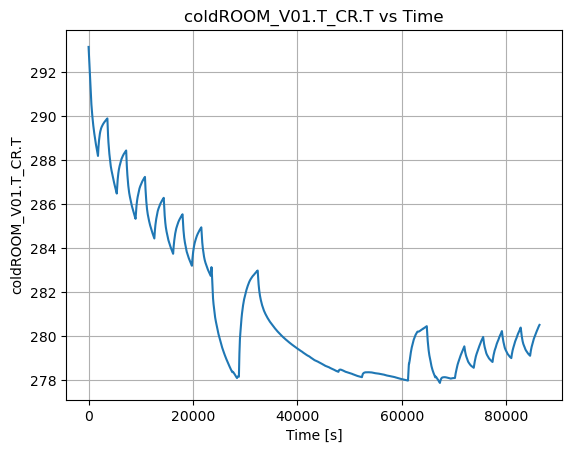

In [15]:


 
# (optional) peek at available variables
# print(res.names())  # uncomment to see all variable names
 
# get time and the parameter
t = res.abscissa(param, 0)[0]   # time vector for 'param'
y = res.data(param)          # values
 
# basic plot
plt.figure()
plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel(param)
plt.title(f"{param} vs Time")
plt.grid(True)
plt.show()

In [18]:
from DyMat import DyMatFile
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re

# --- USER INPUTS ---
folder = Path(r"C:\Users\BakhshZahmatkeshBB\OneDrive - University of Twente\BBZ Data\Deliverable 4_1\Github_Repository_D4-1\AGRI_COOL-D4.1\Sensitivity_analysis\results")
param = "coldROOM_V01.T_CR.T"        # Variable to analyze (exact name in Dymola results)
time_var = "Time"                    # Time variable name in Dymola (usually "Time")
baseline_K = 0.025                   # Baseline K value for sensitivity calculation
pattern = r"matPlyUre_K\s*=\s*([\d\.]+)"  # Pattern to extract K value from filename
# --------------------------------

# Find all .mat files in the folder
mat_files = sorted(folder.glob("*.mat"))
if not mat_files:
    raise FileNotFoundError("No .mat files found in the specified folder.")

results = {}
K_values = []

# --- Load data from all .mat files ---
for f in mat_files:
    match = re.search(pattern, f.name)
    if not match:
        print(f"Skipping {f.name}, no K value found in name.")
        continue

    # Clean up possible trailing '.' (e.g. "0.012500000000.")
    # K_str = match.group(1).rstr_


In [19]:
# Sensitivity analysis across multiple Dymola .mat files
# Author: Bahareh's helper script (for AGRI-COOL project)
# Environment: VS Code

from DyMat import DyMatFile
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re

# --- Make sure interactive plotting works in VS Code ---
matplotlib.use("TkAgg")  # ensures plots appear in VS Code interactive window

# --- USER INPUTS ---
folder = Path(r"C:\Users\BakhshZahmatkeshBB\OneDrive - University of Twente\BBZ Data\Deliverable 4_1\Github_Repository_D4-1\AGRI_COOL-D4.1\Sensitivity_analysis\results")
param = "coldROOM_V01.T_CR.T"        # variable to analyze
time_var = "Time"                    # usually "Time" in Dymola
baseline_K = 0.025                   # baseline value for sensitivity
pattern = r"matPlyUre_K\s*=\s*([\d\.]+)"  # regex to capture numeric K
# --------------------------------

# Find all .mat files
mat_files = sorted(folder.glob("*.mat"))
if not mat_files:
    raise FileNotFoundError("No .mat files found in the specified folder.")

results = {}
K_values = []

print(f"\nFound {len(mat_files)} .mat files:")
for f in mat_files:
    print(" -", f.name)

# --- Load data from all files ---
for f in mat_files:
    match = re.search(pattern, f.name)
    if not match:
        print(f"Skipping {f.name}, no K value found in filename.")
        continue

    # Remove any trailing dot in numeric part
    K_str = match.group(1).rstrip('.')
    try:
        K_val = float(K_str)
    except ValueError:
        print(f"⚠️ Could not parse K value from {f.name}")
        continue

    res = DyMatFile(str(f))
    try:
        t = res.abscissa(param, 0)[0]
        y = res.data(param)
        if len(t) != len(y):
            print(f"⚠️ Skipping {f.name}: time and data length mismatch.")
            continue
        results[K_val] = y
        K_values.append(K_val)
        print(f"Loaded {f.name} → K = {K_val}")
    except Exception as e:
        print(f"Variable {param} not found in {f.name}: {e}")

# --- Verify successful loads ---
if not results:
    raise RuntimeError("No valid data loaded. Check variable name or folder path.")

K_values = sorted(K_values)
print(f"\nSuccessfully loaded runs for K = {K_values}")

# Use last loaded 't' as the time base
t = np.array(t)

# --- Baseline ---
if baseline_K not in results:
    raise ValueError(f"Baseline K = {baseline_K} not found. Choose one of: {K_values}")
y_baseline = results[baseline_K]

# --- Compute time-dependent normalized sensitivity ---
S_t = {}
for K in K_values:
    if K == baseline_K:
        continue
    S_t[K] = ((results[K] - y_baseline) / y_baseline) * (baseline_K / (K - baseline_K))

# --- Plot 1: Temperature vs Time ---
plt.figure(figsize=(10, 5))
for K in K_values:
    plt.plot(t, results[K], label=f"K = {K:.4f}")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature evolution for different matPlyUre_K values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(folder / "Temperature_vs_Time.png", dpi=300)
print("\nSaved figure: Temperature_vs_Time.png")

# --- Plot 2: Time-wise Sensitivity ---
plt.figure(figsize=(10, 5))
for K, S in S_t.items():
    plt.plot(t, S, label=f"S*(t) for K={K:.4f}")
plt.xlabel("Time [s]")
plt.ylabel("Normalized Sensitivity S*(t)")
plt.title(f"Time-wise Sensitivity of {param}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(folder / "Sensitivity_vs_Time.png", dpi=300)
print("Saved figure: Sensitivity_vs_Time.png")

# --- Display both plots interactively ---
plt.show(block=True)



Found 7 .mat files:
 - coldROOM_V01.matPlyUre_K = 0.012500000000.mat
 - coldROOM_V01.matPlyUre_K = 0.016666666667.mat
 - coldROOM_V01.matPlyUre_K = 0.020833333333.mat
 - coldROOM_V01.matPlyUre_K = 0.025000000000.mat
 - coldROOM_V01.matPlyUre_K = 0.029166666667.mat
 - coldROOM_V01.matPlyUre_K = 0.033333333333.mat
 - coldROOM_V01.matPlyUre_K = 0.037500000000.mat
Loaded coldROOM_V01.matPlyUre_K = 0.012500000000.mat → K = 0.0125
Loaded coldROOM_V01.matPlyUre_K = 0.016666666667.mat → K = 0.016666666667
Loaded coldROOM_V01.matPlyUre_K = 0.020833333333.mat → K = 0.020833333333
Loaded coldROOM_V01.matPlyUre_K = 0.025000000000.mat → K = 0.025
Loaded coldROOM_V01.matPlyUre_K = 0.029166666667.mat → K = 0.029166666667
Loaded coldROOM_V01.matPlyUre_K = 0.033333333333.mat → K = 0.033333333333
Loaded coldROOM_V01.matPlyUre_K = 0.037500000000.mat → K = 0.0375

Successfully loaded runs for K = [0.0125, 0.016666666667, 0.020833333333, 0.025, 0.029166666667, 0.033333333333, 0.0375]


ValueError: operands could not be broadcast together with shapes (3280,) (3274,) 

In [22]:
from DyMat import DyMatFile
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re

# --- Ensure plots appear in VS Code ---
matplotlib.use("TkAgg")

# --- USER INPUTS ---
folder = Path(r"C:\Users\BakhshZahmatkeshBB\OneDrive - University of Twente\BBZ Data\Deliverable 4_1\Github_Repository_D4-1\AGRI_COOL-D4.1\Sensitivity_analysis\results")
param = "coldROOM_V01.T_CR.T"
baseline_K = 0.025
pattern = r"matPlyUre_K\s*=\s*([\d\.]+)"
# --------------------------------

mat_files = sorted(folder.glob("*.mat"))
if not mat_files:
    raise FileNotFoundError("No .mat files found in the specified folder.")

results = {}
times = {}
K_values = []

print(f"\nFound {len(mat_files)} .mat files:")
for f in mat_files:
    print(" -", f.name)

# --- Load data ---
for f in mat_files:
    match = re.search(pattern, f.name)
    if not match:
        print(f"Skipping {f.name}, no K value found in filename.")
        continue

    K_str = match.group(1).rstrip('.')
    try:
        K_val = float(K_str)
    except ValueError:
        print(f"⚠️ Could not parse K value from {f.name}")
        continue

    res = DyMatFile(str(f))
    try:
        t = np.array(res.abscissa(param, 0)[0])
        y = np.array(res.data(param))
        results[K_val] = y
        times[K_val] = t
        K_values.append(K_val)
        print(f"Loaded {f.name} → K = {K_val:.5f}, len={len(y)}")
    except Exception as e:
        print(f"⚠️ Variable {param} not found in {f.name}: {e}")

K_values = sorted(K_values)
print(f"\nSuccessfully loaded runs for K = {K_values}")

# --- Baseline setup ---
if baseline_K not in results:
    raise ValueError(f"Baseline K = {baseline_K} not found among loaded runs.")
t_base = times[baseline_K]
y_base = results[baseline_K]

# --- Interpolate all results to the baseline time vector ---
interp_results = {}
for K in K_values:
    if len(times[K]) != len(t_base) or not np.allclose(times[K], t_base):
        interp_results[K] = np.interp(t_base, times[K], results[K])
    else:
        interp_results[K] = results[K]

# --- Compute sensitivity ---
S_t = {}
for K in K_values:
    if K == baseline_K:
        continue
    y_interp = interp_results[K]
    # S_t[K] = ((y_interp - y_base) / y_base) * (baseline_K / (K - baseline_K))
    S_t[K] = ((y_interp - y_base) / y_base) 

# --- Plot 1: Temperature vs Time ---
plt.figure(figsize=(10, 5))
for K in K_values:
    plt.plot(t_base, interp_results[K], label=f"K = {K:.4f}")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature evolution for different matPlyUre_K values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(folder / "Temperature_vs_Time.png", dpi=300)
print("\nSaved: Temperature_vs_Time.png")

# --- Plot 2: Time-wise Sensitivity ---
plt.figure(figsize=(10, 5))
for K, S in S_t.items():
    plt.plot(t_base, S, label=f"S*(t) for K={K:.4f}")
plt.xlabel("Time [s]")
plt.ylabel("Normalized Sensitivity S*(t)")
plt.title(f"Time-wise Sensitivity of {param}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(folder / "Sensitivity_vs_Time.png", dpi=300)
print("Saved: Sensitivity_vs_Time.png")

plt.show(block=True)



Found 7 .mat files:
 - coldROOM_V01.matPlyUre_K = 0.012500000000.mat
 - coldROOM_V01.matPlyUre_K = 0.016666666667.mat
 - coldROOM_V01.matPlyUre_K = 0.020833333333.mat
 - coldROOM_V01.matPlyUre_K = 0.025000000000.mat
 - coldROOM_V01.matPlyUre_K = 0.029166666667.mat
 - coldROOM_V01.matPlyUre_K = 0.033333333333.mat
 - coldROOM_V01.matPlyUre_K = 0.037500000000.mat
Loaded coldROOM_V01.matPlyUre_K = 0.012500000000.mat → K = 0.01250, len=3280
Loaded coldROOM_V01.matPlyUre_K = 0.016666666667.mat → K = 0.01667, len=3277
Loaded coldROOM_V01.matPlyUre_K = 0.020833333333.mat → K = 0.02083, len=3280
Loaded coldROOM_V01.matPlyUre_K = 0.025000000000.mat → K = 0.02500, len=3274
Loaded coldROOM_V01.matPlyUre_K = 0.029166666667.mat → K = 0.02917, len=3272
Loaded coldROOM_V01.matPlyUre_K = 0.033333333333.mat → K = 0.03333, len=3276
Loaded coldROOM_V01.matPlyUre_K = 0.037500000000.mat → K = 0.03750, len=3258

Successfully loaded runs for K = [0.0125, 0.016666666667, 0.020833333333, 0.025, 0.029166666667,